In [1]:
import pandas as pd
import torch
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("11-study_hours_grades.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [4]:
X = torch.tensor(df['study_hours'], dtype = torch.float).unsqueeze(1)
y = torch.tensor(df['grade'], dtype = torch.float).unsqueeze(1)

In [5]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [6]:
len(X_train), len(X_test)

(40, 10)

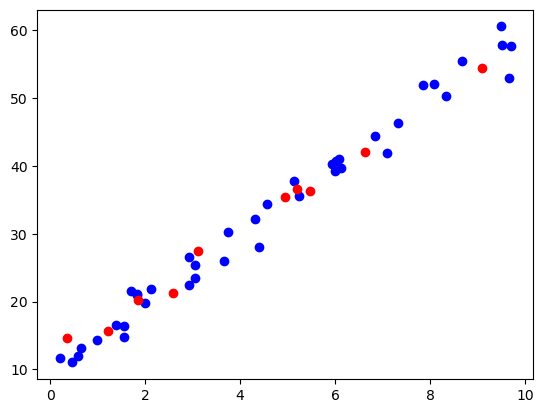

In [7]:
plt.scatter(X_train, y_train, c = "b")
plt.scatter(X_test, y_test, c = "r")
plt.show()

In [8]:
from torch import nn

In [11]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [21]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [22]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [23]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [24]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(
    params = model.parameters(),
    lr = 0.01
)

In [25]:
epochs = 120

for epoch in range(epochs):
    model.train()

    y_pred = model.forward(X_train)    # 1. Forwarding Pass

    loss = loss_fn(y_train, y_pred)   # 2. Calculate the loss

    optimizer.zero_grad()    # 3. Clean the last gradient

    loss.backward()

    optimizer.step()

    model.eval()

    with torch.inference_mode():
        y_test_pred = model(X_test)

        test_loss = loss_fn(y_test_pred, y_test)

    if epoch % 5 == 0:
        print(f"Epoch : {epoch} | Train loss: {loss} | Test loss {test_loss}")

Epoch : 0 | Train loss: 965.6339721679688 | Test loss 160.62022399902344
Epoch : 5 | Train loss: 22.257577896118164 | Test loss 27.251602172851562
Epoch : 10 | Train loss: 21.13695526123047 | Test loss 25.89261245727539
Epoch : 15 | Train loss: 20.168928146362305 | Test loss 24.743696212768555
Epoch : 20 | Train loss: 19.254438400268555 | Test loss 23.6547908782959
Epoch : 25 | Train loss: 18.390506744384766 | Test loss 22.621475219726562
Epoch : 30 | Train loss: 17.574350357055664 | Test loss 21.640789031982422
Epoch : 35 | Train loss: 16.803316116333008 | Test loss 20.709945678710938
Epoch : 40 | Train loss: 16.07491683959961 | Test loss 19.826316833496094
Epoch : 45 | Train loss: 15.386789321899414 | Test loss 18.987407684326172
Epoch : 50 | Train loss: 14.736712455749512 | Test loss 18.190872192382812
Epoch : 55 | Train loss: 14.122581481933594 | Test loss 17.434463500976562
Epoch : 60 | Train loss: 13.54240608215332 | Test loss 16.716089248657227
Epoch : 65 | Train loss: 12.994303

In [26]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[5.6578]])),
             ('linear_layer.bias', tensor([5.7629]))])

In [27]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

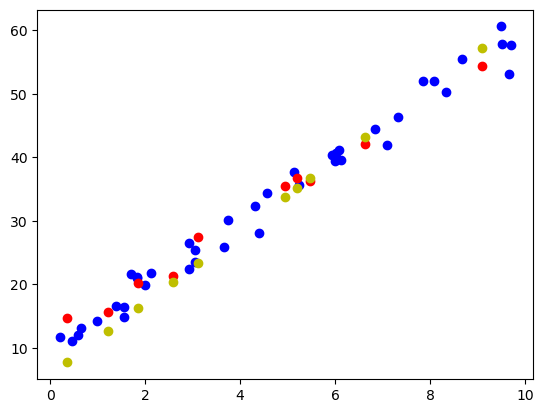

In [28]:
plt.scatter(X_train, y_train, c = "b")
plt.scatter(X_test, y_test, c = "r")
plt.scatter(X_test, y_preds, c = "y")
plt.show()